# Calibrate-Orbitrap-NO3

A notebook to calibrate internal ESI-Orbitrap MS isotopologue delta values of samples, using the measured and true values of isotope standards analysed in a sequence.

Accepts either a single M0 sequence, or M0 and no-M0 sequences of the same samples.

Uses a Monte-Carlo approach (peturbation of input data by their uncertainties with many repeat calculations) to estimate mean and error of each sample's true $\delta$- and $\Delta$-values. 

The Monte-Carlo scheme outputs calibration-associated ±$1\sigma$ errors. These are combined with measurement SEM to give total uncertainties on calibrated values.

Calibrated data are reported in an excel file.

### Inputs:
- results_'YYYY-MM-DD'.xlsx file(s) containing internal isotopologue measurements of a sequence of samples and standards, eiher a single M0 or an M0 and a noM0 sequence for the same samples. Files must be in a subfolder named 'M0' or 'noM0'.
- references_nitrate.xlsx file, with referenced isotope values of the standards measured in the sequence.

### Output:
- 'current-dir'-calibrated-'YYYY-MM-DD'.xlsx, containing sheets for uncalibrated small $\delta$, calibrated small $\delta$, M0 (and no-M0) calibration metadata, and pooled uncertainties

In [5]:
import os
import numpy as np
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from datetime import datetime
current_datetime = datetime.now()
current_date_string = current_datetime.strftime("%Y-%m-%d")

# default colours
defcols = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
   

### Find and import Orbitrap data, merge files, drop outlying rows
For automatic identification of files, they must be in appropriate 'M0' or 'noM0' subfolders, and be named 'results.....xlsx'

In [10]:
# FIND data files, decide if M0 or M0+noM0 data present by folder names
paths=[]
n_M0=0; n_noM0=0
# detect folders on path
folders = [folder for folder in os.listdir() if folder.startswith(('m0','nom0','M0','noM0'))]
for folder in folders:
    # select files within folder
    files = [file for file in sorted(os.listdir(folder)) if file.startswith('results') and file.endswith('.xlsx')]
    if len(files)==1:
        file = files[0]
        print('File',file,'found in folder',folder)
    elif len(files)>1.5:
        file = files[-1]
        print('File',file,'found in folder',folder,'(last file alphabetically selected from multiple files)')
    else:
        print('No file found in',folder)
    paths+=[os.path.join(folder,file)]
    # count instances of M0 or noM0 in folder names
    if folder.startswith(('nom0','noM0')):
        n_noM0+=1
    if folder.startswith(('m0','M0')):
        n_M0+=1
# automatically select data type
if n_noM0>0.5 and n_M0>0.5:
    data_type='M0+noM0'
    print('Data type =',data_type)
elif n_M0>0.5:
    data_type='M0-only'
    print('Data type =',data_type)
else:
    print('error selecting data type')
    
### Or manually input filename
# paths = ['250203_DC-2011-2_HSO4_noM0/results_2025-02-08.xlsx',
#          '250131_DC-2011-2_HSO4_M0/results_2025-02-08.xlsx']
### Or manually input data type
# data_type = 'M0-only'
# data_type = 'M0+noM0'


# IMPORT and MERGE data
data=pd.DataFrame()
data_merged = pd.DataFrame(columns=['sample_name'])

# load data from identified paths into a single dataframe
for path in paths:
    data = pd.concat([data, pd.read_excel(path,sheet_name='Bracketed deltas',index_col='Unnamed: 0')],ignore_index=True)
    print('Data loaded',path)

# join data vertically, adding _basepeak as column suffix for delta columns
for bp in data['basepeak'].unique():
    data_bp = data[data['basepeak']==bp].dropna(axis=1,how='all')
    newcols=[]
    for col in data_bp.columns:
        if col.startswith(('d','err_')):
            col+='_'+bp
            newcols+=[col]
        else:
            newcols+=[col]
    data_bp.columns=newcols
    data_merged = pd.concat([data_merged,data_bp], axis=0, ignore_index=True)
    data_merged.reset_index(inplace=True)

# IF NECESSARY rename samples for alphabetical sorting and to match between data sets
# if False:
#     newnames=[]
#     for name in data_merged.index:
#     #     rename CDD-...
#         if name.startswith('C'):
#             num=name[1:]
#             if '-' in num:
#                 num1=num.split('-')[0]
#                 if len(num1)==1:
#                     num1='00'+num1
#                 if len(num1)==2:
#                     num1='0'+num1
#                 num2=num.split('-')[1]
#                 if len(num2)==1:
#                     num2='00'+num2
#                 if len(num2)==2:
#                     num2='0'+num2
#                 num=num1+'-'+num2
#             else:
#                 if len(num)==1:
#                     num='00'+num
#                 if len(num)==2:
#                     num='0'+num
#             newname = 'CDD-'+num

#         elif name.startswith('ech'):
#             num=name[4:]
#             if '-' in num:
#                 num1=num.split('-')[0]
#                 if len(num1)==1:
#                     num1='00'+num1
#                 if len(num1)==2:
#                     num1='0'+num1
#                 num2=num.split('-')[1]
#                 if len(num2)==1:
#                     num2='00'+num2
#                 if len(num2)==2:
#                     num2='0'+num2
#                 num=num1+'-'+num2
#             else:
#                 if len(num)==1:
#                     num='00'+num
#                 if len(num)==2:
#                     num='0'+num
#             newname = 'CDD-'+num
#         else: 
#             newname=name
#         newnames+=[newname]
#     data_merged.index=newnames

# sort rows alphabetically
data_merged = data_merged.loc[sorted(data_merged.index)]

### OPTIONAL INPUT: DROP any unwanted rows using this code
if False:
    to_drop = [] # by index
    data_merged = data_merged.loc[[row for row in data_merged.index if row not in to_drop]]
    print('Dropped rows:',to_drop)
### OPTIONAL INPUT, DROP any suprious values (replace with NaN)
if False:
    row = []
    col = []
    data_merged.loc[row,col]=np.nan
    print('Removed',row,'-',col)
    
# DISPLAY loaded, merged, cleaned data
disp = pd.concat([data_merged['sample_name'],data_merged[[col for col in data_merged.columns if col.startswith(('d','err_'))]]*1e3],axis=1)

print(disp.head())
print('\n\n\n',disp.tail())

File results_2025-10-21.xlsx found in folder m0 (last file alphabetically selected from multiple files)
File results_2025-10-21.xlsx found in folder nom0 (last file alphabetically selected from multiple files)
Data type = M0+noM0
Data loaded m0/results_2025-10-21.xlsx
Data loaded nom0/results_2025-10-21.xlsx
  sample_name  d15N_M0  d17O_M0  d18O_M0  err_d15N_M0  err_d17O_M0  \
0        C282    -1.27    -1.76     3.45         1.15         2.15   
1        C282    -2.26    -1.25     4.26         1.14         2.13   
2        C282    -2.09    -2.05     2.90         1.14         2.18   
3        C282    -1.39    -2.32     3.57         1.13         2.11   
4        C282     0.33     1.40     3.77         1.13         2.16   

   err_d18O_M0  d17O_15N  d18O_15N  err_d17O_15N  err_d18O_15N  d15N18O_15N  \
0         0.88       NaN       NaN           NaN           NaN          NaN   
1         0.88       NaN       NaN           NaN           NaN          NaN   
2         0.86       NaN       N

### Calculate average values for standards
Each standard was prepared multiple repeat times. This block calculates means and standard error on standard delta values of *all* the injections of each standard

In [11]:
# dictionary for consistent renaming of standards
# if needed, edit to match the names in references and sequence files
stds_dict = {'USGS32':'USGS32','USGS34':'USGS34','USGS35':'USGS35',
             'VS':'VolSol',
             'S1':'SMIF1','SMIF1':'SMIF1','S2':'SMIF2','SMIF2':'SMIF2',
             'Alpha':'Sulf-Alpha','alpha':'Sulf-Alpha','Beta':'Sulf-Beta','beta':'Sulf-Beta','Eps':'Sulf-Epsilon','eps':'Sulf-Epsilon','Epsilon':'Sulf-Epsilon','epsilon':'Sulf-Epsilon',
             'UW4':'SodSul4','U4':'SodSul4','SS4':'SodSul4','UWSS4':'SodSul4','UW8':'SodSul8','U8':'SodSul8','SS8':'SodSul8','UWSS8':'SodSul8'
            }

# identify standard rows
data_stds = data_merged.loc[[row for row in data_merged.index if (data_merged.loc[row,'sample_name'].startswith(tuple(stds_dict.keys())))]]
# remove the -1, -2, -3 suffix from standards
for row in data_stds.index:
    if data_stds.loc[row,'sample_name'].endswith(('-1','-2','-3','-4','-5')):
        data_stds.loc[row,'sample_name']=data_stds.loc[row,'sample_name'][:-2]
                
dcols=[col for col in data_stds.columns if col.startswith('d')]

# 1/sigma^2 weighted mean function
def weighted_mean(val,err):
    val = np.asarray(val.dropna(), dtype=float)
    err = np.asarray(err.dropna(), dtype=float)
    w = 1 / err**2
    mean = np.sum(w * val) / np.sum(w)
    # mean_err = np.sqrt(1/ np.sum(w))
    SEM = np.std(val)/np.sqrt(len(val))

    return mean, SEM

# calculate weigted mean for standards
stds_stats=pd.DataFrame(columns=['mean_'+d for d in dcols]+['err_'+d for d in dcols])
for std, group in data_stds.groupby('sample_name'):
    vals={}
    errs={}
    for d in dcols:
        [mean, err] = weighted_mean(group[d],group['err_'+d])
        vals[d]=mean
        errs[d]=err
                                
    stds_stats.loc[std,['mean_'+d for d in dcols]]=list(vals.values())
    stds_stats.loc[std,['err_'+d for d in dcols]]=list(errs.values())

# display averaged standards
stds_stats*1e3

,mean_d15N_M0,mean_d17O_M0,mean_d18O_M0,mean_d17O_15N,mean_d18O_15N,mean_d15N18O_15N,mean_d17O18O_15N,mean_d18O18O_15N,err_d15N_M0,err_d17O_M0,err_d18O_M0,err_d17O_15N,err_d18O_15N,err_d15N18O_15N,err_d17O18O_15N,err_d18O18O_15N
USGS32,159.17,-35.82,-30.55,-170.47,-164.28,-30.72,-193.33,-187.50,0.60,0.50,0.33,0.32,0.17,0.69,2.32,1.11
USGS34,-3.95,-59.59,-75.22,-56.87,-72.30,-76.73,-129.38,-142.20,0.30,0.58,0.29,0.36,0.19,1.01,1.71,0.89
USGS35,-0.36,-0.17,-0.05,-0.50,-0.38,0.01,-1.06,-1.71,0.31,0.76,0.20,0.27,0.22,1.09,1.89,1.18


### Calculate and display pooled raw stdev and sem (pre-calibration)
Calculation: 

#### $\sqrt{\frac{\sum \sigma_\delta^2}{n}}$

For standard error $\sigma_\delta$ on $\delta$-values, for $n$ different samples

In [12]:
# calculation pooled error for sample raw deltas
stdlist = pd.DataFrame(columns=[col for col in group.columns if col.startswith('d')])
nlist = pd.DataFrame(columns=[col for col in group.columns if col.startswith('d')])

mask = ~data_merged["sample_name"].str.startswith(tuple(stds_dict.keys()))
data_merged_spls = data_merged[mask]

for spl, group in data_merged_spls.groupby('sample_name'):
    stds = group[[col for col in group.columns if col.startswith('d')]].std()
    n = group[[col for col in group.columns if col.startswith('d')]].count()

    stdlist.loc[spl,:]=stds
    nlist.loc[spl,:]=n

pooled_stdevs = (np.sum(stdlist**2,axis=0)/len(stdlist.index))**0.5
pooled_sems = (np.sum(stdlist**2/nlist.where(nlist!=0),axis=0)/len(stdlist.index))**0.5
nM0_av = nlist[[col for col in nlist.columns if col.endswith('M0')]].mean()
nnoM0_av = nlist[[col for col in nlist.columns if not col.endswith('M0')]].mean()

err_av = data_merged_spls[[col for col in data_merged_spls.columns if col.startswith('err')]].mean()
err_av.index = [col[4:] for col in err_av.index]

pooled_errs_precal = pd.DataFrame()

pooled_errs_precal['Average single injection inter-scan SEM']=err_av
pooled_errs_precal['Pooled sample stdev']=pooled_stdevs
pooled_errs_precal['Pooled sample SEM']=pooled_sems
pooled_errs_precal['Average replicates per sample M0']=nM0_av
pooled_errs_precal['Average replicates per sample no-M0']=nnoM0_av
print('Average M0 replicates per sample = ',f"{nM0_av.mean():.1f}")
print('Average no-M0 replicates per sample = ',f"{nnoM0_av.mean():.1f}")
print('Pooled errors pre-calibration:')
pooled_errs_precal[['Average single injection inter-scan SEM','Pooled sample stdev','Pooled sample SEM']]*1e3

Average M0 replicates per sample =  6.0
Average no-M0 replicates per sample =  6.0
Pooled errors pre-calibration:


,Average single injection inter-scan SEM,Pooled sample stdev,Pooled sample SEM
d15N_M0,1.14,1.25,0.51
d17O_M0,2.15,2.13,0.87
d18O_M0,0.88,1.25,0.51
d17O_15N,0.90,0.97,0.40
d18O_15N,0.63,0.78,0.32
d15N18O_15N,3.44,3.43,1.40
d17O18O_15N,9.29,9.84,4.02
d18O18O_15N,4.64,4.30,1.75


### Import reference data for the same standards

Note: for calibration of d15N where only USGS34 (d15N=-1.8) and USGS35 (d15N=2.7) measurements are available, only USGS35 was used for a one-point calibration, fixing the calibration slope empirically at b=1.1
This avoids large uncertainties on calibration slope originating from the small difference in d15N between the 2 standards. A third standard (e.g. USGS32, d15N=180) should be used to better constrain the slope of the calibration.

In [13]:
ref_fn=[fn for fn in os.listdir() if fn.startswith('references_')][-1]
print('References file', ref_fn)

standards = stds_stats.index

refs = pd.read_excel(ref_fn,index_col='sample_name')/1e3
refs = refs[refs.index.isin(stds_stats.index)].loc[standards]

# rename columns
cols=np.array(refs.columns)
for i,col in enumerate(cols):
    if '/' in col:
        col = col.replace('/','_')
    else:
        # col=col+'_M0'
        col=col
    cols[i]=col
refs.columns=cols

refs15N=refs.copy()
# remove USGS34 d15N value if only USGS35 and 34 present (see note above)
if len(refs15N)==2:
    if ('USGS34' in refs.index)&('USGS35' in refs.index):
        refs15N.loc['USGS34','d15N']=np.nan
        refs15N.loc['USGS34','err_d15N']=np.nan
        
refs*1e3

References file references_nitrate.xlsx


,d15N,D17O,d18O,D15N18O,D17O18O,D18O18O,err_d15N,err_D17O,err_d18O,err_D15N18O,err_D17O18O,err_D18O18O
USGS32,180.00,NaN,25.70,0.00,0.00,0.00,0.00,0.20,0.40,0.00,0.00,0.00
USGS34,-1.80,-0.30,-27.90,0.00,0.00,0.00,0.20,0.20,0.60,0.00,0.00,0.00
USGS35,2.70,21.60,57.50,NaN,NaN,NaN,0.20,NaN,0.40,NaN,NaN,NaN


## Calibration calculation

Model:
#### $ y + 1 = (x + 1 )^b e^a$  
or
#### $ \log(y + 1 )= b \log(x+1)+ a$  
with  
#### $y=\delta_{true} ; x=\delta_{meas}$

Calculation: 

- if 1 (x,y) point: prescribe a gradient b and invert for intercept a
- if 2+ (x,y) points: linear regression of $log(y+1)$ against $log(x+1)$
- if 3+ (x,y) points: can use the fit of the points to the regression line to quantify the quality of the linear calibration

Monte-Carlo approach: repeat calculation $nn$ times with inputs normally peturbed by their $1\sigma$ uncertainties. Best results with $nn>1000$.

For each repeat, store calculated slope (=b) and intercept (=log(1+a)) for each sample in a list, average the list and take its standard deviation at the end

Reference $\delta$ values which are unavailable (e.g. $\delta^{15}N^{18}O$) are calculated during the calibration, using measured $\delta$ values and reference $\Delta$ values

### Prepare DataFrames and functions for calibration

In [26]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# INPUT number of bootstraps - use nn > 1000 for best results (calculation time c. 5ms per iteration per isotopologue)
nn=100

# Prep calibrated samples dataframe
# filter and order columns
d_columns=[col for col in data_merged.columns if (col.startswith(('d')))]
err_columns=[col for col in data_merged.columns if (col.startswith(('err')))]
samples = data_merged.loc[:,d_columns+err_columns]

# define calibration function
def  calib_regression(x_data,y_data):
    x_vals=[]; y_vals=[];
    x_data_clean=pd.Series(x_data).dropna()
    y_data_clean=pd.Series(y_data).dropna()
    for standard in y_data_clean.index:
        # linear calibration of log(1+delta)
        x_vals.append(np.log(1 + x_data_clean.loc[standard]))
        y_vals.append(np.log(1 + y_data_clean.loc[standard]))
    x_vals = np.array(x_vals).reshape(-1,1)
    y_vals = np.array(y_vals).reshape(-1,1)
    
    if len(x_vals)>2.5:
         # linear regression
        reg = LinearRegression()
        reg.fit(x_vals, y_vals)
        slope=reg.coef_[0]
        intercept=reg.intercept_
        #  RMS residual
        y_pred = slope * x_vals + intercept
        residuals = y_vals - y_pred
        rmse = np.sqrt(np.mean(residuals**2))
    elif len(x_vals)>1.5:
        # linear regression
        reg = LinearRegression()
        reg.fit(x_vals, y_vals)
        slope=reg.coef_[0]
        intercept=reg.intercept_
        rmse = np.nan
    else:
        # 1-point calibration - INPUT PRESCRIBED SLOPE HERE for all isotopologues, or below if specific values for each isotopologue
        slope=np.array([1.1])
        intercept=np.array([y_vals[0]-x_vals[0]*slope])
        rmse = np.nan
    
    return [slope, intercept, rmse]

# results dataframes setup
columns = [col for col in samples.columns if (col in ['d15N_M0','d18O_M0','d17O_M0','d17O_15N','d18O_15N','d15N18O_15N','d18O18O_15N'])]+['D17O_M0']
rows_sam = samples.index
rows_std = stds_stats.index
samples_cal=pd.DataFrame([[[] for _ in range(len(columns))] for _ in range(len(rows_sam))], columns=columns, index=rows_sam)
stds_cal=pd.DataFrame([[[] for _ in range(len(columns))] for _ in range(len(rows_std))], columns=columns, index=rows_std)

### M0 calibrations

15N; 18O; 17O (using d18O measurements and reference D17O to calculate reference d17O)


/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/f

Mean intercept d15N: 2.81
Mean slope d15N: 1.10


/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/jacksaville/anaconda3/lib/python3.11/site-packages/numpy/core/f

Pooled errors:              Average single injection inter-scan SEM Pooled sample stdev  \
d15N_M0                                         1.14                1.25   
d17O_M0                                         2.15                2.13   
d18O_M0                                         0.88                1.25   
d17O_15N                                        0.90                0.97   
d18O_15N                                        0.63                0.78   
d15N18O_15N                                     3.44                3.43   
d17O18O_15N                                     9.29                9.84   
d18O18O_15N                                     4.64                4.30   
D17O_M0                                          NaN                 NaN   

            Pooled sample SEM  Average replicates per sample M0  \
d15N_M0                  0.51                           6000.00   
d17O_M0                  0.87                           6000.00   
d18O_M0                

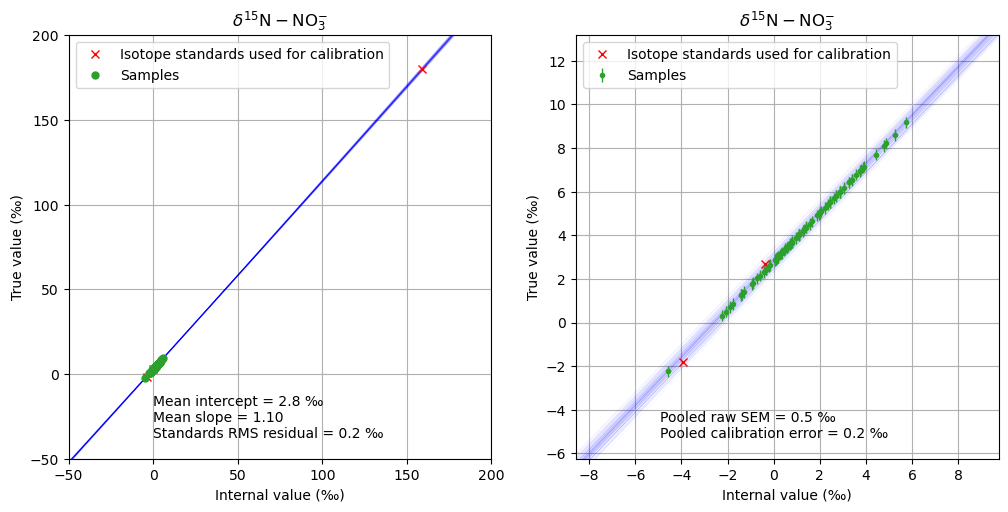

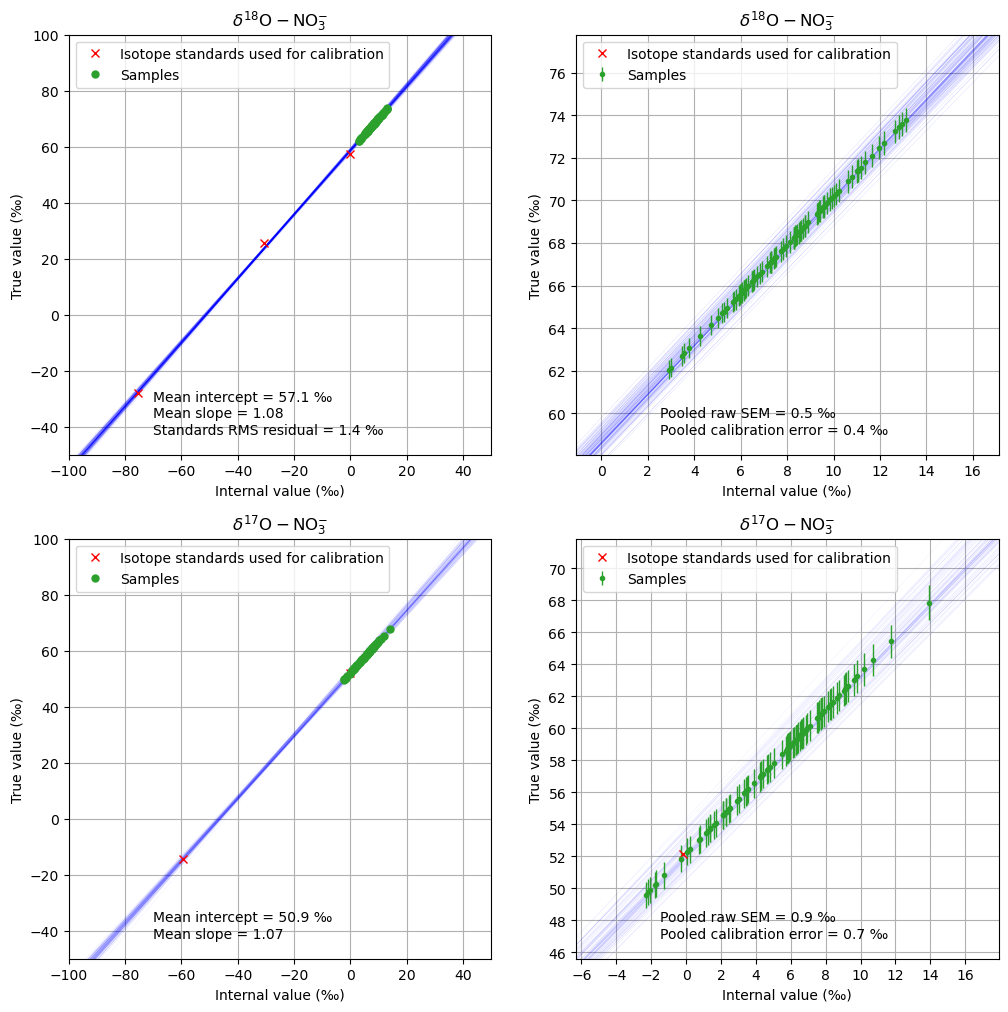

In [27]:
bp='M0'

### Nitrogen calibration
slope_15=[];intercept_15=[];rmse_15=[]

# plot for calib curves
fig1,ax=plt.subplots(1,2,figsize=[12,5.5])
ax[0].grid()
ax[0].set_xlabel('Internal value (‰)')
ax[0].set_ylabel('True value (‰)')
ax[1].grid()
ax[1].set_xlabel('Internal value (‰)')
ax[1].set_ylabel('True value (‰)')
ax[0].set_title('$\delta^{15}\mathrm{N-NO_{3}^{-}}$')
ax[1].set_title('$\delta^{15}\mathrm{N-NO_{3}^{-}}$')

for n in range(nn):
    ## 15N  calibration:
    iso='15N'
    # linear regression
    x_data=np.random.normal(stds_stats['mean_d'+iso+'_'+bp],stds_stats['err_d'+iso+'_'+bp])
    y_data=np.random.normal(refs15N['d'+iso],refs15N['err_d'+iso])
    [slope, intercept, rmse] = calib_regression(x_data,y_data) 
    # OPTIONAL INPUT to force the slope or intercept for a specific isotopologue ratio, enter the values and their uncertainty and use these lines
    if False:
        slope[0]=np.random.normal(1,0)
        intercept[0]=np.random.normal(0,0)
    # store values in lists
    slope_15+=[slope[0]]
    intercept_15+=[intercept[0]]
    rmse_15+=[rmse]
    
    # add line to plot
    x=np.linspace(-100,200,100)*1e-3
    y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
    ax[0].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=10/nn)
    ax[1].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=10/nn)
    
    # CALIBRATE STDS and SAMPLES
    stds_stats_pet=pd.DataFrame(index=stds_stats.index)
    stds_stats_pet['mean_d15N_M0'] = np.random.normal(stds_stats['mean_d15N_M0'],stds_stats['err_d15N_M0'])
    for row in stds_cal.index:
        stds_cal.loc[row,'d15N_M0'] += [(stds_stats_pet.loc[row,'mean_d15N_M0']+1)**slope_15[-1] * np.exp(intercept_15[-1])-1]
    
    samples_pet=samples.copy() # no peturbing samples as we will take sem later
    for row in samples_cal.index:
        samples_cal.loc[row,'d15N_M0'] += [(samples_pet.loc[row,'d15N_M0']+1)**slope_15[-1] * np.exp(intercept_15[-1])-1]
        
def averaging(df):
    df2=pd.DataFrame(columns=[col for col in df.columns]+[col+'_err' for col in df.columns], index=df.index)
    for row in df.index:
        for col in df.columns:
            df2.loc[row,col] = np.mean(df.loc[row,col])
            df2.loc[row,col+'_err'] = np.std(df.loc[row,col])
            # df2.loc[row,col] = np.median(df.loc[row,col])
            # df2.loc[row,col+'_err'] = np.percentile(df.loc[row,col],75)-np.percentile(df.loc[row,col],25)
    return df2

samples_cal_final=0; stds_cal_final=0;
samples_cal_final = averaging(samples_cal)
stds_cal_final = averaging(stds_cal)
s_new = samples_cal_final.loc[data_merged_spls.index]
s_old = samples.loc[data_merged_spls.index]

# add points for standards    
ax[0].errorbar(stds_stats['mean_d15N_M0']*1e3,refs['d15N']*1e3,
                   linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')

ax[1].errorbar(stds_stats['mean_d15N_M0']*1e3,refs['d15N']*1e3,
                   linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')
# and samples
## and samples
ax[0].errorbar(s_old['d15N_M0']*1e3,s_new['d15N_M0']*1e3, 
                  linestyle='',fmt='o',markersize=5,c=defcols[2],label='Samples') 
ax[1].errorbar(s_old['d15N_M0']*1e3,s_new['d15N_M0']*1e3, 
                  yerr = s_new['d15N_M0_err']*1e3, 
                  ls='',lw=1,fmt='o',markersize=3,c=defcols[2],label='Samples') 

# calculation pooled calib error
cols = [ col for col in samples_cal_final.columns if col.endswith('err')]
rows = data_merged_spls.index
errs = samples_cal_final.loc[rows,cols]
# Compute post-calibration pooled error
pooled_err_calib = pd.DataFrame(
    (np.sum(errs**2, axis=0) / len(errs.index))**0.5,
    columns=['Pooled MC calibration error'])
pooled_err_calib.index = [ind[:-4] for ind in pooled_err_calib.index]
# Merge the two df
pooled_errs = pd.concat([pooled_errs_precal,pooled_err_calib],axis=1)

ax[0].set_xlim([-50,200])
ax[0].set_ylim([-50,200])
ax[1].set_xlim([s_old['d15N_M0'].min()*1e3-4,s_old['d15N_M0'].max()*1e3+4])
ax[1].set_ylim([s_new['d15N_M0'].min()*1e3-4,s_new['d15N_M0'].max()*1e3+4])
ax[0].legend(loc='upper left')
ax[1].legend(loc='upper left')
ax[1].xaxis.set_major_locator(MultipleLocator(2))
ax[1].yaxis.set_major_locator(MultipleLocator(2))

locx=0.2;locy=0.05


ax[0].text(x=locx,y=locy,
              s=
              'Mean intercept = '+f"{np.mean(intercept_15)*1e3:.1f}"+' ‰'+'\n'+
              'Mean slope = '+f"{np.mean(slope_15):.2f}\n"+
              'Standards RMS residual = 'f"{np.mean(rmse_15)*1e3:.1f}"+' ‰',
              transform=ax[0].transAxes)
             
ax[1].text(x=locx,y=locy,
              s=
              'Pooled raw SEM = '+f"{pooled_errs.loc['d15N_M0','Pooled sample SEM']*1e3:.1f}"+' ‰\n'+
              'Pooled calibration error = '+f"{pooled_errs.loc['d15N_M0','Pooled MC calibration error']*1e3:.1f}"+' ‰',
              transform=ax[1].transAxes)


print('Mean intercept d15N:', f"{np.mean(intercept_15)*1e3:.2f}")
print('Mean slope d15N:', f"{np.mean(slope_15):.2f}")





### Oxygen calibration

slope_17=[];slope_18=[];intercept_17=[];intercept_18=[];rmse_18=[];rmse_17=[]

# for calib curves
fig2,ax=plt.subplots(2,2,figsize=[12,12])
for axis in ax:
    axis[0].grid()
    axis[0].set_xlabel('Internal value (‰)')
    axis[0].set_ylabel('True value (‰)')
    axis[1].grid()
    axis[1].set_xlabel('Internal value (‰)')
    axis[1].set_ylabel('True value (‰)')
ax[0][0].set_title('$\delta^{18}\mathrm{O-NO_{3}^{-}}$')
ax[1][0].set_title('$\delta^{17}\mathrm{O-NO_{3}^{-}}$')
ax[0][1].set_title('$\delta^{18}\mathrm{O-NO_{3}^{-}}$')
ax[1][1].set_title('$\delta^{17}\mathrm{O-NO_{3}^{-}}$')

for n in range(nn):
    ## 18O  calibration:
    iso='18O'
    # linear regression
    x_data=np.random.normal(stds_stats['mean_d'+iso+'_'+bp],stds_stats['err_d'+iso+'_'+bp])
    y_data=np.random.normal(refs['d'+iso],refs['err_d'+iso])
    # call to regression func
    [slope, intercept, rmse] = calib_regression(x_data,y_data) 
    # store values in lists
    slope_18+=[slope[0]]
    intercept_18+=[intercept[0]]
    rmse_18+=[rmse]
    
    # calibrate standard 18O values - 
    d18_cal =  (stds_stats['mean_d'+iso+'_'+bp]+1)**slope_18[-1] * np.exp(intercept_18[-1])-1
    
    # add line to plot
    x=np.linspace(-100,100,100)*1e-3
    y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
    ax[0][0].plot(x*1e3,y*1e3,lw=0.2,alpha=0.2,c='b')
    ax[0][1].plot(x*1e3,y*1e3,lw=0.2,alpha=0.2,c='b')

    # 17O linear calibration based on known D17O values
    iso = '17O'   
    D_values = pd.Series(np.random.normal(refs['D17O'].dropna(), refs['err_D17O'].dropna()), index=refs['D17O'].dropna().index)
    #  calculate d17O values for standards, based on calibrated d18O measurement and known D17O.
    d_calc_stds = pd.Series(index=stds_stats.index,dtype='float64').rename_axis('sample_name')
    for std in [std for std in stds_stats.index if std in D_values.index]:
        d_calc_stds.loc[std] = D_values.loc[std] + 0.52 * d18_cal.loc[std]
    if False:
        print('True',iso, 'calculated for standards, based on calibrated measurements and known D17O:\n',d_calc_stds*1e3)
    # regression
    x_data=np.random.normal(stds_stats['mean_d17O_M0'],stds_stats['err_d17O_M0'])
    y_data=np.random.normal(d_calc_stds,0)
    [slope, intercept, rmse] = calib_regression(x_data,y_data) 
    # store values in lists
    slope_17+=[slope[0]]
    intercept_17+=[intercept[0]]
    rmse_17+=[rmse]
   
    # add line to plot
    x=np.linspace(-100,100,100)*1e-3
    y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
    ax[1][0].plot(x*1e3,y*1e3,lw=0.2,alpha=10/nn,c='b')
    ax[1][1].plot(x*1e3,y*1e3,lw=0.2,alpha=10/nn,c='b')
    
    # CALIBRATE STDS and SAMPLES using model and the (a,b) obtained from regression; add delta values to lists to be averaged
    stds_stats_pet=pd.DataFrame(index=stds_stats.index)
    stds_stats_pet['mean_d18O_M0'] = np.random.normal(stds_stats['mean_d18O_M0'],stds_stats['err_d18O_M0'])
    stds_stats_pet['mean_d17O_M0'] = np.random.normal(stds_stats['mean_d17O_M0'],stds_stats['err_d17O_M0'])
    for row in stds_cal.index:
        stds_cal.loc[row,'d18O_M0'] += [(stds_stats_pet.loc[row,'mean_d18O_M0']+1)**slope_18[-1] * np.exp(intercept_18[-1])-1]
        stds_cal.loc[row,'d17O_M0'] += [(stds_stats_pet.loc[row,'mean_d17O_M0']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1]
        stds_cal.loc[row,'D17O_M0'] += [(stds_stats_pet.loc[row,'mean_d17O_M0']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1 - 0.52*((stds_stats_pet.loc[row,'mean_d18O_M0']+1)**slope_18[-1]* np.exp(intercept_18[-1])-1) ]
    
    samples_pet=samples   # no peturbation here
    for row in samples.index:
        samples_cal.loc[row,'d18O_M0'] += [(samples_pet.loc[row,'d18O_M0']+1)**slope_18[-1] * np.exp(intercept_18[-1])-1]
        samples_cal.loc[row,'d17O_M0'] += [(samples_pet.loc[row,'d17O_M0']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1]
        samples_cal.loc[row,'D17O_M0'] += [(samples_pet.loc[row,'d17O_M0']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1 - 0.52*((samples_pet.loc[row,'d18O_M0']+1)**slope_18[-1]* np.exp(intercept_18[-1])-1) ]
    
def averaging(df):
    df2=pd.DataFrame(columns=[col for col in df.columns]+[col+'_err' for col in df.columns], index=df.index)
    for row in df.index:
        for col in df.columns:
            df2.loc[row,col] = np.mean(df.loc[row,col])
            df2.loc[row,col+'_err'] = np.std(df.loc[row,col])
            # df2.loc[row,col] = np.median(df.loc[row,col])
            # df2.loc[row,col+'_err'] = np.percentile(df.loc[row,col],75)-np.percentile(df.loc[row,col],25)
    return df2

samples_cal_final=0; stds_cal_final=0;
samples_cal_final =averaging(samples_cal)
stds_cal_final = averaging(stds_cal)
s_new = samples_cal_final.loc[data_merged_spls.index]
s_old = samples.loc[data_merged_spls.index]
    
# add points for standards    
ax[0][0].errorbar(stds_stats['mean_d18O_M0']*1e3,refs['d18O']*1e3,
                   linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')

ax[0][1].errorbar(stds_stats['mean_d18O_M0']*1e3,refs['d18O']*1e3,
                   linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')
# and samples
## and samples
ax[0][0].errorbar(s_old['d18O_M0']*1e3,s_new['d18O_M0']*1e3, 
                  linestyle='',fmt='o',markersize=5,c=defcols[2],label='Samples') 
ax[0][1].errorbar(s_old['d18O_M0']*1e3,s_new['d18O_M0']*1e3, 
                  yerr = s_new['d18O_M0_err']*1e3, 
                  ls='',lw=1,fmt='o',markersize=3,c=defcols[2],label='Samples') 

# d17O points - calc
d17O_stds_calc = refs['D17O']+0.52*np.array([np.mean(stds_cal.loc[std,'d18O_M0']) for std in stds_cal.index])
ax[1][0].errorbar(stds_stats['mean_d17O_M0']*1e3,d17O_stds_calc*1e3,
                   c='r',linestyle='none',marker='x',label='Isotope standards used for calibration')    
ax[1][1].errorbar(stds_stats['mean_d17O_M0']*1e3,d17O_stds_calc*1e3,
                   c='r',linestyle='none',marker='x',label='Isotope standards used for calibration')    
## and samples
ax[1][0].errorbar(s_old['d17O_M0']*1e3,s_new['d17O_M0']*1e3, 
                  linestyle='',fmt='o',markersize=5,c=defcols[2],label='Samples') 
ax[1][1].errorbar(s_old['d17O_M0']*1e3,s_new['d17O_M0']*1e3, 
                  yerr = s_new['d17O_M0_err']*1e3, 
                  ls='',lw=1,fmt='o',markersize=3,c=defcols[2],label='Samples') 


# calculation pooled calib error
cols = [ col for col in samples_cal_final.columns if col.endswith('err')]
rows = data_merged_spls.index
errs = samples_cal_final.loc[rows,cols]
# Compute post-calibration pooled error
pooled_err_calib = pd.DataFrame(
    (np.sum(errs**2, axis=0) / len(errs.index))**0.5,
    columns=['Pooled MC calibration error'])
pooled_err_calib.index = [ind[:-4] for ind in pooled_err_calib.index]
# Merge the two df
pooled_errs = pd.concat([pooled_errs_precal,pooled_err_calib],axis=1)
# display 
print('Pooled errors:',pooled_errs * 1e3)


mean_metadata_M0 = {'Intercept 15N':np.mean(intercept_15),
                    'Slope 15N':np.mean(slope_15),
                    'Intercept 18O':np.mean(intercept_18),
                    'Slope 18O':np.mean(slope_18),
                    'Intercept 17O':np.mean(intercept_17),
                    'Slope 17O':np.mean(slope_17)}

ax[0][0].legend(loc='upper left')
ax[0][1].legend(loc='upper left')
ax[0][0].set_xlim([-100,50])
ax[0][0].set_ylim([-50,100])
ax[0][1].xaxis.set_major_locator(MultipleLocator(2))
ax[0][1].yaxis.set_major_locator(MultipleLocator(2))
ax[0][1].set_xlim([s_old['d18O_M0'].min()*1e3-4,s_old['d18O_M0'].max()*1e3+4])
ax[0][1].set_ylim([s_new['d18O_M0'].min()*1e3-4,s_new['d18O_M0'].max()*1e3+4])
ax[1][0].legend(loc='upper left')
ax[1][1].legend(loc='upper left')
ax[1][0].set_xlim([-100,50])
ax[1][0].set_ylim([-50,100])
ax[1][1].xaxis.set_major_locator(MultipleLocator(2))
ax[1][1].yaxis.set_major_locator(MultipleLocator(2))
ax[1][1].set_xlim([s_old['d17O_M0'].min()*1e3-4,s_old['d17O_M0'].max()*1e3+4])
ax[1][1].set_ylim([s_new['d17O_M0'].min()*1e3-4,s_new['d17O_M0'].max()*1e3+4])


locx=0.2;locy=0.05

ax[0][0].text(x=locx,y=locy,
              s=
              'Mean intercept = '+f"{np.mean(intercept_18)*1e3:.1f}"+' ‰'+'\n'+
              'Mean slope = '+f"{np.mean(slope_18):.2f}\n"+
              'Standards RMS residual = 'f"{np.mean(rmse_18)*1e3:.1f}"+' ‰',
              transform=ax[0][0].transAxes)
             
ax[1][0].text(x=locx,y=locy,
              s=
              'Mean intercept = '+f"{np.mean(intercept_17)*1e3:.1f}"+' ‰'+'\n'+
              'Mean slope = '+f"{np.mean(slope_17):.2f}",
              transform=ax[1][0].transAxes)
             
ax[0][1].text(x=locx,y=locy,
              s=
              'Pooled raw SEM = '+f"{pooled_errs.loc['d18O_M0','Pooled sample SEM']*1e3:.1f}"+' ‰\n'+
              'Pooled calibration error = '+f"{pooled_errs.loc['d18O_M0','Pooled MC calibration error']*1e3:.1f}"+' ‰',
              transform=ax[0][1].transAxes)

ax[1][1].text(x=locx,y=locy,
              s=
              'Pooled raw SEM = '+f"{pooled_errs.loc['d17O_M0','Pooled sample SEM']*1e3:.1f}"+' ‰\n'+
              'Pooled calibration error = '+f"{pooled_errs.loc['d17O_M0','Pooled MC calibration error']*1e3:.1f}"+' ‰',
              transform=ax[1][1].transAxes)

             

print('Mean intercept d18O:', f"{np.mean(intercept_18)*1e3:.2f}")
print('Mean slope d18O:', f"{np.mean(slope_18):.2f}")
print('Mean intercept d17O:', f"{np.mean(intercept_17)*1e3:.2f}")
print('Mean slope d17O:', f"{np.mean(slope_17):.2f}")

# fig1.savefig('Calib15N.png',dpi=450)
# fig2.savefig('Calib17O18O.png',dpi=450)

### no-M0 calibrations (if M0+noM0 data)
17O/15N; 18O/15N; 15N18O/15N; 18O18O/15N

Note: 1-point clumped isotopologue calibrations are likely to be inaccurate for samples far from the point - prefer 2 point calibrations (e.g. USGS34+USGS32)

Pooled errors:              Average single injection inter-scan SEM Pooled sample stdev  \
d15N_M0                                         1.14                1.25   
d17O_M0                                         2.15                2.13   
d18O_M0                                         0.88                1.25   
d17O_15N                                        0.90                0.97   
d18O_15N                                        0.63                0.78   
d15N18O_15N                                     3.44                3.43   
d17O18O_15N                                     9.29                9.84   
d18O18O_15N                                     4.64                4.30   
D17O_M0                                          NaN                 NaN   

            Pooled sample SEM  Average replicates per sample M0  \
d15N_M0                  0.51                           6000.00   
d17O_M0                  0.87                           6000.00   
d18O_M0                

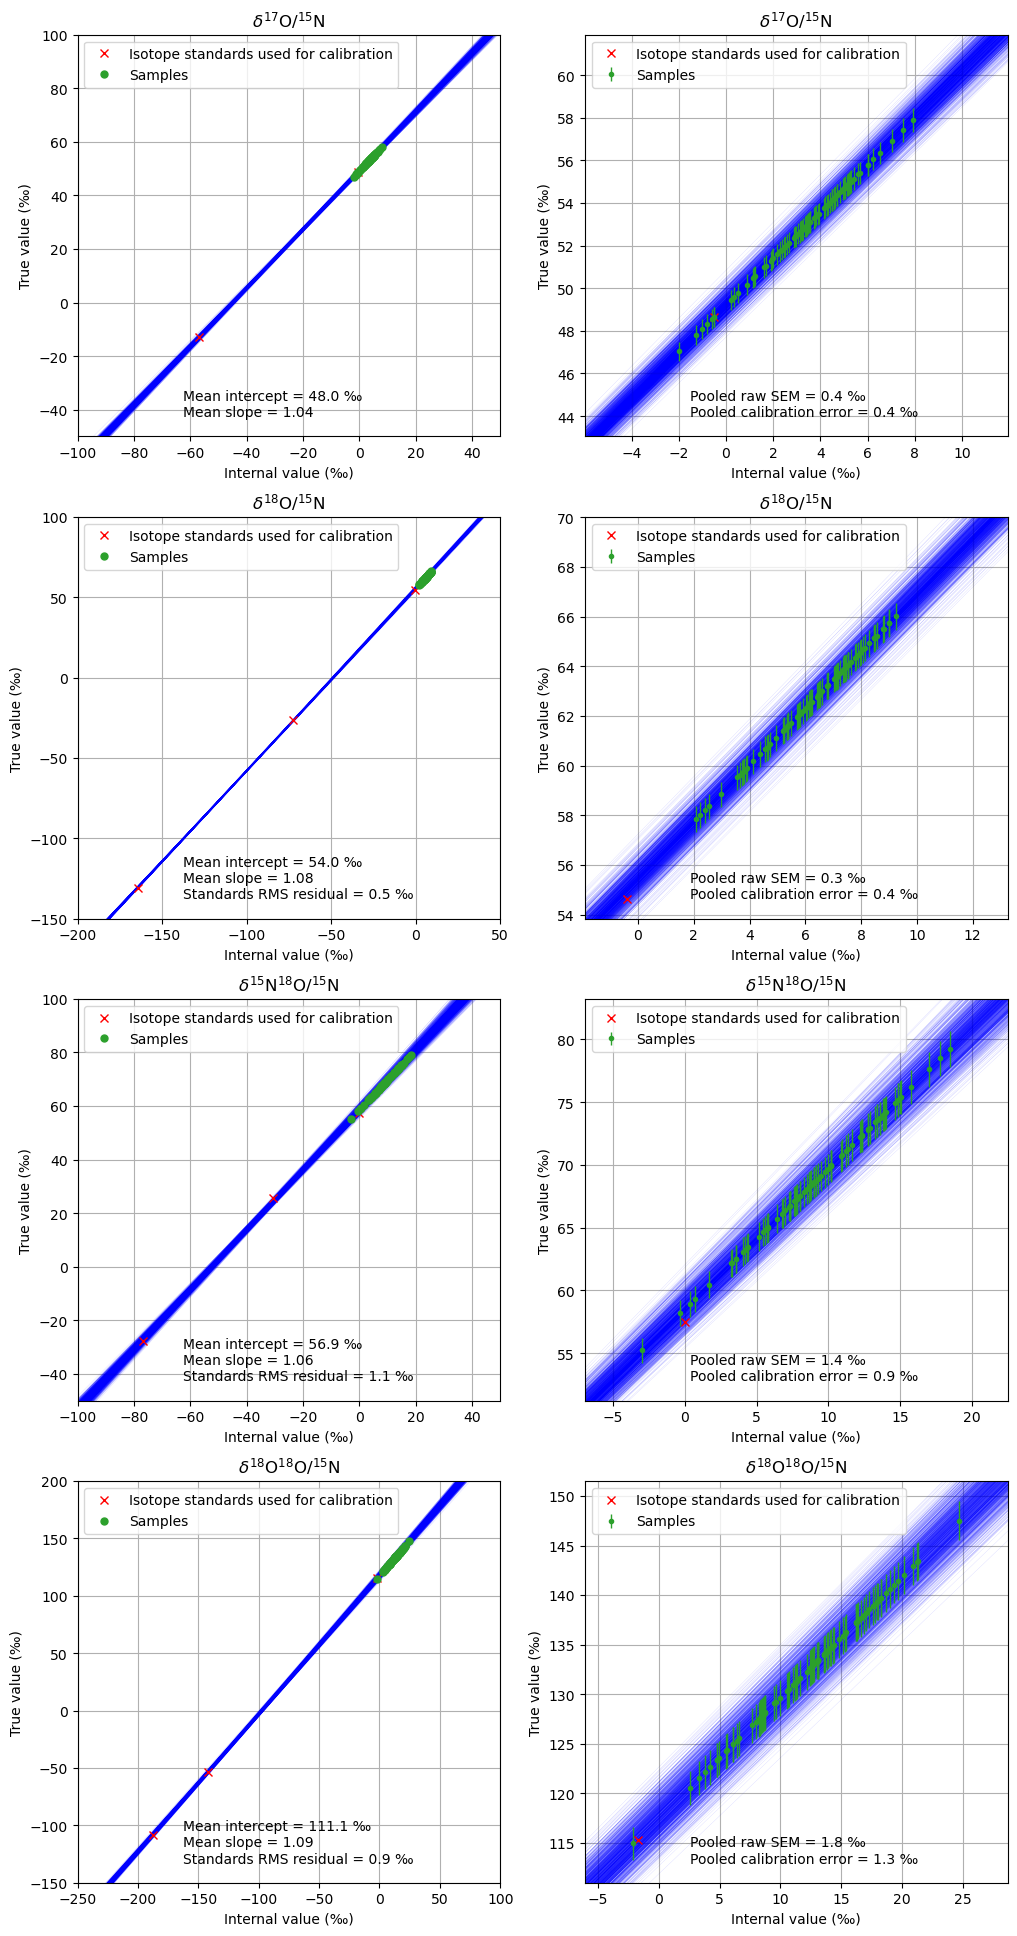

In [16]:
if data_type=='M0+noM0':

    # noM0 calibrations
    slope_17=[];slope_18=[];slope_1518=[];slope_1818=[]
    intercept_17=[];intercept_18=[];intercept_1518=[];intercept_1818=[]
    rmse_17=[];rmse_18=[];rmse_1518=[];rmse_1818=[]

    # for calib curves
    fig3,ax=plt.subplots(4,2,figsize=[12,24])
    for axis in ax:
        for axis in axis:
            axis.grid()
            axis.set_xlabel('Internal value (‰)')
            axis.set_ylabel('True value (‰)')
    ax[0][0].set_title('$\delta^{17}\mathrm{O/}^{15}\mathrm{N}$')
    ax[0][1].set_title('$\delta^{17}\mathrm{O/}^{15}\mathrm{N}$')
    ax[1][0].set_title('$\delta^{18}\mathrm{O/}^{15}\mathrm{N}$')
    ax[1][1].set_title('$\delta^{18}\mathrm{O/}^{15}\mathrm{N}$')
    ax[2][0].set_title('$\delta^{15}\mathrm{N}^{18}\mathrm{O/}^{15}\mathrm{N}$')
    ax[2][1].set_title('$\delta^{15}\mathrm{N}^{18}\mathrm{O/}^{15}\mathrm{N}$')
    ax[3][0].set_title('$\delta^{18}\mathrm{O}^{18}\mathrm{O/}^{15}\mathrm{N}$')
    ax[3][1].set_title('$\delta^{18}\mathrm{O}^{18}\mathrm{O/}^{15}\mathrm{N}$')


    for n in range(nn):

        #     17O/15N
        d15 = pd.Series(np.random.normal(refs['d15N'].dropna(), refs['err_d15N'].dropna()), index=refs['d15N'].dropna().index)
        d18 = pd.Series(np.random.normal(refs['d18O'].dropna(), refs['err_d18O'].dropna()), index=refs['d18O'].dropna().index)
        D17 = pd.Series(np.random.normal(refs['D17O'].dropna(), refs['err_D17O'].dropna()), index=refs['D17O'].dropna().index)
        d_calc_stds = pd.Series(index=stds_stats.index,dtype='float64').rename_axis('sample_name')

        for std in [std for std in stds_stats.index if std in D17.index]:
            d_calc_stds.loc[std] = ((1+(D17.loc[std]+0.52*d18.loc[std])) / (1+d15.loc[std]) -1)
        # regression
        x_data=np.random.normal(stds_stats['mean_d17O_15N'],stds_stats['err_d17O_15N'])
        y_data=np.random.normal(d_calc_stds,0)

        [slope, intercept,rmse] = calib_regression(x_data,y_data)  
        # store values in lists 
        slope_17+=[slope[0]]
        intercept_17+=[intercept[0]]
        rmse_17+=[rmse]

        # add line to plot
        x=np.linspace(-200,200,100)*1e-3
        y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
        ax[0][0].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)
        ax[0][1].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)

        #     18O/15N
        d15 = pd.Series(np.random.normal(refs['d15N'].dropna(), refs['err_d15N'].dropna()), index=refs['d15N'].dropna().index)
        d18 = pd.Series(np.random.normal(refs['d18O'].dropna(), refs['err_d18O'].dropna()), index=refs['d18O'].dropna().index)
        d_calc_stds = pd.Series(index=stds_stats.index,dtype='float64').rename_axis('sample_name')

        for std in [std for std in stds_stats.index if std in d18.index]:
            d_calc_stds.loc[std] = ((1+d18.loc[std]) / (1+d15.loc[std]) -1)
        # regression
        x_data=np.random.normal(stds_stats['mean_d18O_15N'],stds_stats['err_d18O_15N'])
        y_data=np.random.normal(d_calc_stds,0)

        [slope, intercept,rmse] = calib_regression(x_data,y_data)  
        # store values in lists 
        slope_18+=[slope[0]]
        intercept_18+=[intercept[0]]
        rmse_18+=[rmse]

        # add line to plot
        x=np.linspace(-200,100,100)*1e-3
        y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
        ax[1][0].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)
        ax[1][1].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)

        # 15N18O/15N
        d18 = pd.Series(np.random.normal(refs['d18O'].dropna(), refs['err_d18O'].dropna()), index=refs['d18O'].dropna().index)
        d_calc_stds = d18

        # regression
        x_data=np.random.normal(stds_stats['mean_d15N18O_15N'],stds_stats['err_d15N18O_15N'])
        y_data=np.random.normal(d_calc_stds,0)

        [slope, intercept,rmse] = calib_regression(x_data,y_data)  
        # store values in lists 
        slope_1518+=[slope[0]]
        intercept_1518+=[intercept[0]]
        rmse_1518+=[rmse]

        # add line to plot
        x=np.linspace(-100,100,100)*1e-3
        y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
        ax[2][0].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)
        ax[2][1].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)

           # 18O18O/15N
        d18 = pd.Series(np.random.normal(refs['d18O'].dropna(), refs['err_d18O'].dropna()), index=refs['d18O'].dropna().index)
        d15 = pd.Series(np.random.normal(refs['d15N'].dropna(), refs['err_d15N'].dropna()), index=refs['d15N'].dropna().index)
        d_calc_stds = (1+d18)**2/(1+d15)-1
        # regression
        x_data=np.random.normal(stds_stats['mean_d18O18O_15N'],stds_stats['err_d18O18O_15N'])
        y_data=np.random.normal(d_calc_stds,0)

        [slope, intercept,rmse] = calib_regression(x_data,y_data)  
        # store values in lists 
        slope_1818+=[slope[0]]
        intercept_1818+=[intercept[0]]
        rmse_1818+=[rmse]

        # add line to plot
        x=np.linspace(-300,100,100)*1e-3
        y= ( (1+x)**slope[0]*np.exp(intercept[0])-1 )
        ax[3][0].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)
        ax[3][1].plot(x*1e3,y*1e3,c='b',lw=0.2,alpha=0.2)


        # CALIBRATE STDS and SAMPLES using model and the (a,b) obtained from regression; add delta values to lists to be averaged
        stds_stats_pet=pd.DataFrame(index=stds_stats.index)
        stds_stats_pet['mean_d17O_15N'] = np.random.normal(stds_stats['mean_d17O_15N'],stds_stats['err_d17O_15N'])
        stds_stats_pet['mean_d18O_15N'] = np.random.normal(stds_stats['mean_d18O_15N'],stds_stats['err_d18O_15N'])
        stds_stats_pet['mean_d15N18O_15N'] = np.random.normal(stds_stats['mean_d15N18O_15N'],stds_stats['err_d15N18O_15N'])
        stds_stats_pet['mean_d18O18O_15N'] = np.random.normal(stds_stats['mean_d18O18O_15N'],stds_stats['err_d18O18O_15N'])

        for row in stds_cal.index:
            stds_cal.loc[row,'d17O_15N'] += [(stds_stats_pet.loc[row,'mean_d17O_15N']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1]
            stds_cal.loc[row,'d18O_15N'] += [(stds_stats_pet.loc[row,'mean_d18O_15N']+1)**slope_18[-1] * np.exp(intercept_18[-1])-1]
            stds_cal.loc[row,'d15N18O_15N'] += [(stds_stats_pet.loc[row,'mean_d15N18O_15N']+1)**slope_1518[-1] * np.exp(intercept_1518[-1])-1]
            stds_cal.loc[row,'d18O18O_15N'] += [(stds_stats_pet.loc[row,'mean_d18O18O_15N']+1)**slope_1818[-1] * np.exp(intercept_1818[-1])-1]

        samples_pet=samples
        for row in samples.index:
            samples_cal.loc[row,'d17O_15N'] += [(samples_pet.loc[row,'d17O_15N']+1)**slope_17[-1] * np.exp(intercept_17[-1])-1]
            samples_cal.loc[row,'d18O_15N'] += [(samples_pet.loc[row,'d18O_15N']+1)**slope_18[-1] * np.exp(intercept_18[-1])-1]
            samples_cal.loc[row,'d15N18O_15N'] += [(samples_pet.loc[row,'d15N18O_15N']+1)**slope_1518[-1] * np.exp(intercept_1518[-1])-1]
            samples_cal.loc[row,'d18O18O_15N'] += [(samples_pet.loc[row,'d18O18O_15N']+1)**slope_1818[-1] * np.exp(intercept_1818[-1])-1]

            
    def averaging(df):
        df2=pd.DataFrame(columns=[col for col in df.columns]+[col+'_err' for col in df.columns], index=df.index)
        for row in df.index:
            for col in df.columns:
                df2.loc[row,col] = np.mean(df.loc[row,col])
                df2.loc[row,col+'_err'] = np.std(df.loc[row,col])
                # df2.loc[row,col] = np.median(df.loc[row,col])
                # df2.loc[row,col+'_err'] = np.percentile(df.loc[row,col],75)-np.percentile(df.loc[row,col],25)
        return df2

    samples_cal_final=0; stds_cal_final=0;
    samples_cal_final =averaging(samples_cal)
    stds_cal_final = averaging(stds_cal)
    s_new = samples_cal_final.loc[data_merged_spls.index]
    s_old = samples.loc[data_merged_spls.index]
    
    # 17/15 points on curves - calc
    d1715_stds_calc = ( 1 + refs['D17O']+0.52*refs['d18O'] ) / (1+refs['d15N']) -1
    # add points for standards    
    ax[0][0].errorbar(stds_stats['mean_d17O_15N']*1e3,d1715_stds_calc*1e3,
                       linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')

    ax[0][1].errorbar(stds_stats['mean_d17O_15N']*1e3,d1715_stds_calc*1e3,
                   linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')
    ## and samples
    ax[0][0].errorbar(s_old['d17O_15N']*1e3,s_new['d17O_15N']*1e3, 
                      linestyle='',fmt='o',markersize=5,c=defcols[2],label='Samples') 
    ax[0][1].errorbar(s_old['d17O_15N']*1e3,s_new['d17O_15N']*1e3, 
                      yerr = s_new['d17O_15N_err']*1e3, 
                      ls='',lw=1,fmt='o',markersize=3,c=defcols[2],label='Samples') 
 
    # 18/15 points on curves - calc
    d1815_stds_calc = ( 1 + refs['d18O'] ) / (1+refs['d15N']) -1
    # add points for standards    
    ax[1][0].errorbar(stds_stats['mean_d18O_15N']*1e3,d1815_stds_calc*1e3,
                       linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')

    ax[1][1].errorbar(stds_stats['mean_d18O_15N']*1e3,d1815_stds_calc*1e3,
                   linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')
    ## and samples
    ax[1][0].errorbar(s_old['d18O_15N']*1e3,s_new['d18O_15N']*1e3, 
                      linestyle='',fmt='o',markersize=5,c=defcols[2],label='Samples') 
    ax[1][1].errorbar(s_old['d18O_15N']*1e3,s_new['d18O_15N']*1e3, 
                     yerr = s_new['d18O_15N_err']*1e3, 
                      ls='',lw=1,fmt='o',markersize=3,c=defcols[2],label='Samples') 

    # 1518/15 points on curves
    stds_names = [std for std in ['USGS32','USGS34','USGS35'] if std in refs.index]
    d151815_stds_calc = refs.loc[stds_names,'d18O']
        # add points for standards    
    ax[2][0].errorbar(stds_stats.loc[stds_names,'mean_d15N18O_15N']*1e3,d151815_stds_calc*1e3,
                       linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')

    ax[2][1].errorbar(stds_stats.loc[stds_names,'mean_d15N18O_15N']*1e3,d151815_stds_calc*1e3,
                       linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')
    ## and samples
    ax[2][0].errorbar(s_old['d15N18O_15N']*1e3,s_new['d15N18O_15N']*1e3, 
                      linestyle='',fmt='o',markersize=5,c=defcols[2],label='Samples') 
    ax[2][1].errorbar(s_old['d15N18O_15N']*1e3,s_new['d15N18O_15N']*1e3, 
                      yerr = s_new['d15N18O_15N_err']*1e3, 
                      ls='',lw=1,fmt='o',markersize=3,c=defcols[2],label='Samples') 

    
    # 1818/15 points on curves
    stds_names = [std for std in ['USGS32','USGS34','USGS35'] if std in refs.index]
    d181815_stds_calc = (1+refs.loc[stds_names,'d18O'])**2/(1+refs.loc[stds_names,'d15N'])-1
    # add points for standards    
    ax[3][0].errorbar(stds_stats.loc[stds_names,'mean_d18O18O_15N']*1e3,d181815_stds_calc*1e3,
                       linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')

    ax[3][1].errorbar(stds_stats.loc[stds_names,'mean_d18O18O_15N']*1e3,d181815_stds_calc*1e3,
                       linestyle='none',marker='x',c='r',label='Isotope standards used for calibration')
    ## and samples
    ax[3][0].errorbar(s_old['d18O18O_15N']*1e3,s_new['d18O18O_15N']*1e3, 
                      linestyle='',fmt='o',markersize=5,c=defcols[2],label='Samples') 
    ax[3][1].errorbar(s_old['d18O18O_15N']*1e3,s_new['d18O18O_15N']*1e3, 
                      yerr = s_new['d18O18O_15N_err']*1e3, 
                      ls='',lw=1,fmt='o',markersize=3,c=defcols[2],label='Samples') 

    # calculation pooled calib error
    cols = [ col for col in samples_cal_final.columns if col.endswith('err')]
    rows = data_merged_spls.index
    errs = samples_cal_final.loc[rows,cols]
    # Compute post-calibration pooled error
    pooled_err_calib = pd.DataFrame(
        (np.sum(errs**2, axis=0) / len(errs.index))**0.5,
        columns=['Pooled MC calibration error'])
    pooled_err_calib.index = [ind[:-4] for ind in pooled_err_calib.index]
    # Merge the two df
    pooled_errs = pd.concat([pooled_errs_precal,pooled_err_calib],axis=1)
    # display 
    print('Pooled errors:',pooled_errs * 1e3)

    mean_metadata_noM0 = {'Intercept 18O/15N':np.mean(intercept_18),
                        'Slope 18O/15N':np.mean(slope_18),
                        'Intercept 17O/15N':np.mean(intercept_17),
                        'Slope 17O/15N':np.mean(slope_17),
                          'Intercept 15N18O/15N':np.mean(intercept_1518),
                        'Slope 15N18O/15N':np.mean(slope_1518),
                        'Intercept 18O18O/15N':np.mean(intercept_1818),
                        'Slope 18O18O/15N':np.mean(slope_1818)}

    print('Mean intercept d17O/15N:', f"{np.mean(intercept_17)*1e3:.2f}")
    print('Mean slope d17O/15N:', f"{np.mean(slope_17):.2f}")
    print('Mean intercept d18O/15N:', f"{np.mean(intercept_18)*1e3:.2f}")
    print('Mean slope d18O/15N:', f"{np.mean(slope_18):.2f}")
    print('Mean intercept d15N18O/15N:', f"{np.mean(intercept_1518)*1e3:.2f}")
    print('Mean slope d15N8O/15N:', f"{np.mean(slope_1518):.2f}")
    print('Mean intercept d18O18O/15N:', f"{np.mean(intercept_1818)*1e3:.2f}")
    print('Mean slope d18O8O/15N:', f"{np.mean(slope_1818):.2f}")
    
    
    ax[0][0].legend(loc='upper left')
    ax[0][1].legend(loc='upper left')
    ax[0][0].set_xlim([-100,50])
    ax[0][0].set_ylim([-50,100])
    ax[0][1].xaxis.set_major_locator(MultipleLocator(2))
    ax[0][1].yaxis.set_major_locator(MultipleLocator(2))
    ax[0][1].set_xlim([s_old['d17O_15N'].min()*1e3-4,s_old['d17O_15N'].max()*1e3+4])
    ax[0][1].set_ylim([s_new['d17O_15N'].min()*1e3-4,s_new['d17O_15N'].max()*1e3+4])
    
    ax[1][0].legend(loc='upper left')
    ax[1][1].legend(loc='upper left')
    ax[1][0].set_xlim([-200,50])
    ax[1][0].set_ylim([-150,100])
    ax[1][1].xaxis.set_major_locator(MultipleLocator(2))
    ax[1][1].yaxis.set_major_locator(MultipleLocator(2))
    ax[1][1].set_xlim([s_old['d18O_15N'].min()*1e3-4,s_old['d18O_15N'].max()*1e3+4])
    ax[1][1].set_ylim([s_new['d18O_15N'].min()*1e3-4,s_new['d18O_15N'].max()*1e3+4])
    
    ax[2][0].legend(loc='upper left')
    ax[2][1].legend(loc='upper left')
    ax[2][0].set_xlim([-100,50])
    ax[2][0].set_ylim([-50,100])
    ax[2][1].xaxis.set_major_locator(MultipleLocator(5))
    ax[2][1].yaxis.set_major_locator(MultipleLocator(5))
    ax[2][1].set_xlim([s_old['d15N18O_15N'].min()*1e3-4,s_old['d15N18O_15N'].max()*1e3+4])
    ax[2][1].set_ylim([s_new['d15N18O_15N'].min()*1e3-4,s_new['d15N18O_15N'].max()*1e3+4])

    ax[3][0].legend(loc='upper left')
    ax[3][1].legend(loc='upper left')
    ax[3][0].set_xlim([-250,100])
    ax[3][0].set_ylim([-150,200])
    ax[3][1].xaxis.set_major_locator(MultipleLocator(5))
    ax[3][1].yaxis.set_major_locator(MultipleLocator(5))
    ax[3][1].set_xlim([s_old['d18O18O_15N'].min()*1e3-4,s_old['d18O18O_15N'].max()*1e3+4])
    ax[3][1].set_ylim([s_new['d18O18O_15N'].min()*1e3-4,s_new['d18O18O_15N'].max()*1e3+4])


    locx=0.25;locy=0.05

    ax[0][0].text(x=locx,y=locy,
                  s=
                  'Mean intercept = '+f"{np.mean(intercept_17)*1e3:.1f}"+' ‰'+'\n'+
                  'Mean slope = '+f"{np.mean(slope_17):.2f}",
                  transform=ax[0][0].transAxes)
    ax[1][0].text(x=locx,y=locy,
                  s=
                  'Mean intercept = '+f"{np.mean(intercept_18)*1e3:.1f}"+' ‰'+'\n'+
                  'Mean slope = '+f"{np.mean(slope_18):.2f}\n"+
                  'Standards RMS residual = ' + f"{np.mean(rmse_18)*1e3:.1f}"+' ‰',
                  transform=ax[1][0].transAxes)
    ax[2][0].text(x=locx,y=locy,
                  s=
                  'Mean intercept = '+f"{np.mean(intercept_1518)*1e3:.1f}"+' ‰'+'\n'+
                  'Mean slope = '+f"{np.mean(slope_1518):.2f}\n"+
                  'Standards RMS residual = '+f"{np.mean(rmse_1518)*1e3:.1f}"+' ‰',
                  transform=ax[2][0].transAxes)
    ax[3][0].text(x=locx,y=locy,
                  s=
                  'Mean intercept = '+f"{np.mean(intercept_1818)*1e3:.1f}"+' ‰'+'\n'+
                  'Mean slope = '+f"{np.mean(slope_1818):.2f}\n"+
                  'Standards RMS residual = '+f"{np.mean(rmse_1818)*1e3:.1f}"+' ‰',
                  transform=ax[3][0].transAxes)

    ax[0][1].text(x=locx,y=locy,
              s=
              'Pooled raw SEM = '+f"{pooled_errs.loc['d17O_15N','Pooled sample SEM']*1e3:.1f}"+' ‰\n'+
              'Pooled calibration error = '+f"{pooled_errs.loc['d17O_15N','Pooled MC calibration error']*1e3:.1f}"+' ‰',
              transform=ax[0][1].transAxes)
    ax[1][1].text(x=locx,y=locy,
              s=
              'Pooled raw SEM = '+f"{pooled_errs.loc['d18O_15N','Pooled sample SEM']*1e3:.1f}"+' ‰\n'+
              'Pooled calibration error = '+f"{pooled_errs.loc['d18O_15N','Pooled MC calibration error']*1e3:.1f}"+' ‰',
              transform=ax[1][1].transAxes) 
    ax[2][1].text(x=locx,y=locy,
              s=
              'Pooled raw SEM = '+f"{pooled_errs.loc['d15N18O_15N','Pooled sample SEM']*1e3:.1f}"+' ‰\n'+
              'Pooled calibration error = '+f"{pooled_errs.loc['d15N18O_15N','Pooled MC calibration error']*1e3:.1f}"+' ‰',
              transform=ax[2][1].transAxes)
    ax[3][1].text(x=locx,y=locy,
              s=
              'Pooled raw SEM = '+f"{pooled_errs.loc['d18O18O_15N','Pooled sample SEM']*1e3:.1f}"+' ‰\n'+
              'Pooled calibration error = '+f"{pooled_errs.loc['d18O18O_15N','Pooled MC calibration error']*1e3:.1f}"+' ‰',
              transform=ax[3][1].transAxes)
 
    
    
    # fig3.savefig('CalibNO3-noM0.png',dpi=450)


else:
    print('Block skipped because no no-M0 data loaded')

## Averaging the $nn$ $\delta$-values for each isotopologue ratio
Calculates mean and standard deviation (alternatively median and IQR) of $nn$ values for each isotopologue ratio for each sample or standard

In [17]:
def averaging(df):
    df2=pd.DataFrame(columns=[col for col in df.columns]+[col+'_err' for col in df.columns], index=df.index)
    for row in df.index:
        for col in df.columns:
            df2.loc[row,col] = np.mean(df.loc[row,col])
            df2.loc[row,col+'_err'] = np.std(df.loc[row,col])
            # df2.loc[row,col] = np.median(df.loc[row,col])
            # df2.loc[row,col+'_err'] = np.percentile(df.loc[row,col],75)-np.percentile(df.loc[row,col],25)
    return df2

samples_cal_final=0; stds_cal_final=0;
samples_cal_final =averaging(samples_cal)
stds_cal_final = averaging(stds_cal)

samples['sample_name']=data_merged['sample_name']
samples['blockname']=data_merged['blockname']
samples_cal_final['sample_name']=data_merged['sample_name']
samples_cal_final['blockname']=data_merged['blockname']
pd.concat([samples_cal_final[['sample_name','blockname']],samples_cal_final[[col for col in samples_cal_final.columns if col not in ('blockname','sample_name')]] *1e3],axis=1)
                                                               
                                                               

,sample_name,blockname,d15N_M0,d17O_M0,d18O_M0,d17O_15N,d18O_15N,d15N18O_15N,d18O18O_15N,D17O_M0,d15N_M0_err,d17O_M0_err,d18O_M0_err,d17O_15N_err,d18O_15N_err,d15N18O_15N_err,d18O18O_15N_err,D17O_M0_err
0,C282,250117_079,1.42,50.32,62.69,NaN,NaN,NaN,NaN,17.71,0.28,0.90,0.46,NaN,NaN,NaN,NaN,0.85
1,C282,250117_219,0.33,50.89,63.62,NaN,NaN,NaN,NaN,17.81,0.28,0.91,0.47,NaN,NaN,NaN,NaN,0.86
2,C282,250117_185,0.52,49.99,62.06,NaN,NaN,NaN,NaN,17.72,0.28,0.90,0.46,NaN,NaN,NaN,NaN,0.85
3,C282,250117_179,1.29,49.69,62.83,NaN,NaN,NaN,NaN,17.02,0.28,0.89,0.46,NaN,NaN,NaN,NaN,0.84
4,C282,250117_131,3.19,53.86,63.06,NaN,NaN,NaN,NaN,21.07,0.28,0.95,0.46,NaN,NaN,NaN,NaN,0.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,USGS35-2,250121_235,NaN,NaN,NaN,47.07,53.44,52.81,108.52,NaN,NaN,NaN,NaN,0.46,0.50,0.96,1.61,NaN
236,USGS35-2,250121_165,NaN,NaN,NaN,47.65,55.08,62.83,120.76,NaN,NaN,NaN,NaN,0.46,0.50,1.12,1.72,NaN
237,USGS35-2,250121_189,NaN,NaN,NaN,48.52,55.46,52.44,115.71,NaN,NaN,NaN,NaN,0.47,0.50,0.95,1.67,NaN
238,USGS35-2,250121_187,NaN,NaN,NaN,49.10,53.47,59.22,111.65,NaN,NaN,NaN,NaN,0.47,0.50,1.06,1.64,NaN


### Calculate and display pooled uncertainties pre-and post-calibration

Calculation: 

#### $\sqrt{\frac{\sum \sigma_\delta^2}{n}}$

For standard error $\sigma_\delta$ on $\delta$-values, for $n$ different samples

In [18]:
# calculate D17O errors
std17=[]
sem17=[]
D17O_stats=pd.DataFrame(columns=['mean_'+d for d in dcols]+['err_'+d for d in dcols])
samples_cal_final_samples_only = samples_cal_final[~ samples_cal_final['sample_name'].str.startswith(tuple(stds_dict.keys()))]
for spl, group in samples_cal_final_samples_only.groupby('sample_name'):
    std17 += [group['D17O_M0'].std()]
    sem17 += [group['D17O_M0'].std() /np.sqrt( len(group)) ]
std17 = pd.Series(std17).dropna()
sem17 = pd.Series(sem17).dropna()
pooled_std17 = np.sqrt(np.sum(std17**2)/len(std17))
pooled_sem17 = np.sqrt(np.sum(sem17**2)/len(sem17))
pooled_errs.loc['D17O_M0','Pooled sample stdev'] = pooled_std17
pooled_errs.loc['D17O_M0','Pooled sample SEM'] = pooled_sem17


# combine the two error types
pooled_errs['Total uncertainty = sqrt( SEM^2 + MC^2 )']=(pooled_errs['Pooled sample SEM']**2+pooled_errs['Pooled MC calibration error']**2)**0.5


print('Pooled errors:')
pooled_errs[['Average single injection inter-scan SEM','Pooled sample stdev','Pooled sample SEM','Pooled MC calibration error','Total uncertainty = sqrt( SEM^2 + MC^2 )']]*1e3
            

Pooled errors:


,Average single injection inter-scan SEM,Pooled sample stdev,Pooled sample SEM,Pooled MC calibration error,Total uncertainty = sqrt( SEM^2 + MC^2 )
d15N_M0,1.14,1.25,0.51,0.20,0.55
d17O_M0,2.15,2.13,0.87,0.72,1.13
d18O_M0,0.88,1.25,0.51,0.35,0.62
d17O_15N,0.90,0.97,0.40,0.36,0.53
d18O_15N,0.63,0.78,0.32,0.37,0.49
d15N18O_15N,3.44,3.43,1.40,0.86,1.64
d17O18O_15N,9.29,9.84,4.02,NaN,NaN
d18O18O_15N,4.64,4.30,1.75,1.29,2.18
D17O_M0,NaN,2.44,0.70,0.68,0.98


## Save to excel file

In [19]:
output_file = os.getcwd().split('/')[-1]+'_calibrated_'+data_type+'_'+current_date_string+'.xlsx'

if data_type=='M0+noM0':
    to_save = {'Small deltas uncalibrated':samples,
               'Small deltas calibrated':samples_cal_final,
               'Calibration metadata M0': pd.DataFrame(mean_metadata_M0.items()),
              'Calibration metadata no-M0': pd.DataFrame(mean_metadata_noM0.items()),
              'Pooled raw errors': pooled_errs}
else:
    to_save = {'Small deltas uncalibrated':samples,
               'Small deltas calibrated':samples_cal_final,
               'Calibration metadata M0': pd.DataFrame(mean_metadata_M0.items()),
              'Pooled errors': pooled_errs              }

for sheet_name, df in to_save.items():
    # Check if the file exists
    if not os.path.exists(os.path.join(output_file)):
        # If the file doesn't exist, create a new ExcelWriter object without mode='a'
        with pd.ExcelWriter(os.path.join(output_file), engine='openpyxl') as writer:
            # Write the DataFrame to a new sheet with the specified sheet name
            df.to_excel(writer, sheet_name=sheet_name, index=True)
            print('Excel file created:',os.path.join(output_file),'\nNew sheet added to',output_file,':',sheet_name)
    else:
        # If the file exists, create an ExcelWriter object with mode='a' to append to the existing file
        with pd.ExcelWriter(os.path.join(output_file), engine='openpyxl', mode='a',if_sheet_exists='replace') as writer:
            # Write the DataFrame to a new sheet with the specified sheet name
            df.to_excel(writer, sheet_name=sheet_name, index=True)
            print('New sheet added to',output_file,':',sheet_name)

Excel file created: nitrate_calibrated_M0+noM0_2026-04-10.xlsx 
New sheet added to nitrate_calibrated_M0+noM0_2026-04-10.xlsx : Small deltas uncalibrated
New sheet added to nitrate_calibrated_M0+noM0_2026-04-10.xlsx : Small deltas calibrated
New sheet added to nitrate_calibrated_M0+noM0_2026-04-10.xlsx : Calibration metadata M0
New sheet added to nitrate_calibrated_M0+noM0_2026-04-10.xlsx : Calibration metadata no-M0
New sheet added to nitrate_calibrated_M0+noM0_2026-04-10.xlsx : Pooled raw errors
